In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pylab import *
import os

import math
from pylab import *
from scipy.integrate import odeint
from tqdm.notebook import tqdm, trange
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks

# 1. Wilson-Cowan Neuroanl E-I model

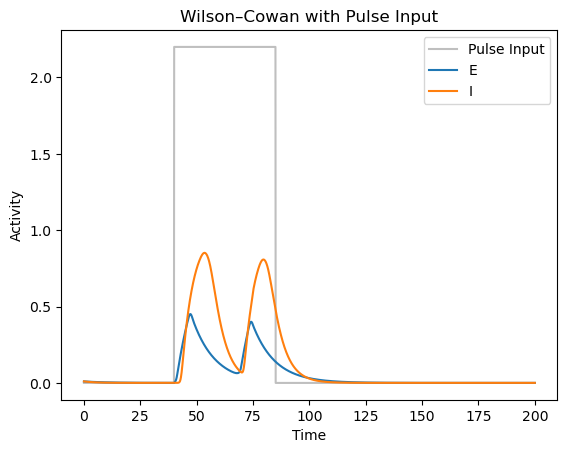

<Figure size 650x300 with 0 Axes>

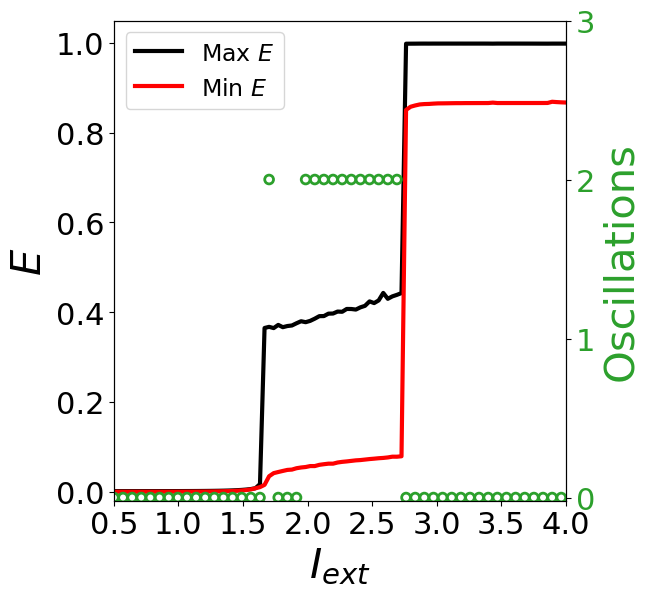

In [2]:
def S(x, a, theta):
    return 1 / (1 + np.exp(-a * (x - theta)))

# -----------------------
# Parameters
# -----------------------

tau_E = 10.0
tau_I = 5.0

w_EE = 13.0
w_EI = 10.0
w_IE = 10.0
w_II = 0.0

a_E = 6.0
a_I = 4.0

theta_E = 2.5
theta_I = 2.0

def wilson_cowan(t, y, I_ext):
    E, I = y

    dE = (-E + S(w_EE*E - w_EI*I + I_ext, a_E, theta_E)) / tau_E
    dI = (-I + S(w_IE*E - w_II*I, a_I, theta_I)) / tau_I

    return [dE, dI]

def pulse_input(t, start, duration, amp):
    """return amplitude while t is within [start, start+duration]"""
    return amp if (start < t < start + duration) else 0.0

def wc_with_pulse(t, y, start, duration, amp):
    return wilson_cowan(t, y, pulse_input(t, start, duration, amp))


def WC_Solve(T_max, step, pulse_start, pulse_duration, pulse_amp, Plot=False):
    Pts = int(np.floor(T_max/step))

    t_span = (0.0, T_max)
    t_eval = np.linspace(*t_span, Pts)
    # integrate, passing the pulse parameters via a lambda
    sol = solve_ivp(lambda t, y: wc_with_pulse(t, y,
                                            pulse_start,
                                            pulse_duration,
                                            pulse_amp),
                    t_span, y0, t_eval=t_eval)

    # generate pulse input series for plotting
    pulse_input_series = np.array([pulse_input(ti,
                                            pulse_start,
                                            pulse_duration,
                                            pulse_amp)
                                for ti in t_eval])
    time = np.array(sol.t)
    Input = np.array(pulse_input_series)
    Sol = np.array([sol.y[0], sol.y[1]])

    if Plot == True:
        WC_TS_plot(time, Input, Sol)
    return time, Input, Sol

def WC_TS_plot(time, Input, Sol):
    plt.figure()
    fig_size = plt.rcParams["figure.figsize"]  
    fig_size[0] = 6.5
    fig_size[1] = 3
    plt.plot(time, Input, label='Pulse Input', color='grey', alpha=0.5)
    plt.plot(time, Sol[0], label="E")
    plt.plot(time, Sol[1], label="I")
    plt.xlabel("Time")
    plt.ylabel("Activity")
    plt.title("Wilson–Cowan with Pulse Input")
    plt.legend()
    plt.show()

# -----------------------
# 2️. Bifurcation Sweep
# -----------------------
###bifurcation 
def Bifrcation_Sweep(pulse_duration):
    I_values = np.linspace(0.5, 4, 100)
    E_max = []
    E_min = []
    E_period = []
    for I_ext in I_values:
        sol = solve_ivp(
            lambda t, y: wilson_cowan(t, y, I_ext),
            (0, 200),
            [0.01, 0.01],
            t_eval=[200]
        )
        ###max and min value when the pulse is on (20 < t < 80)
        sol = solve_ivp(lambda t, y: wilson_cowan(t, y, I_ext), (0, 200), [0.01, 0.01], t_eval=np.linspace(0, 200, 2000))
        ###find beginning of pulse period (t=20) and end of pulse period (t=80) in the t_eval array
        Pulse_begin_idx = np.where(sol.t >= 20)[0][0]
        Pulse_end_idx = np.where(sol.t >= 20 + pulse_duration)[0][0]
        E_max.append(np.max(sol.y[0, Pulse_begin_idx:Pulse_end_idx]))
        E_min.append(np.min(sol.y[0, Pulse_begin_idx:Pulse_end_idx]))

        ###obtain period of oscillation when the pulse is on (20 < t < 80)
        # Find peaks in E during the pulse period
        from scipy.signal import find_peaks
        peaks, _ = find_peaks(sol.y[0, Pulse_begin_idx:Pulse_end_idx], height=0.1)
        if len(peaks) > 1:
            periods = np.diff(peaks) * (200/2000)  # Convert index difference to time
            ###also calculate number of oscillations during the pulse period
            E_period.append(len(peaks))
            # E_period.append(np.mean(periods))
        else:        E_period.append(0)  # No oscillation or only one peak
    return I_values, E_max, E_min, E_period


def plot_bifurcation(I_values, E_max, E_min, E_period):
    plt.figure()
    fig_size = plt.rcParams["figure.figsize"]  
    fig_size[0] = 6.5
    fig_size[1] = 6
    plt.rcParams["figure.figsize"] = fig_size  
    fig, ax1 = plt.subplots()
    ax1.set_xlabel("$I_{ext}$", fontsize=30)    
    ax1.set_ylabel("$E$", fontsize=30, color='k')
    ax1.plot(I_values, E_max, linewidth=3, label='Max $E$', color='k')
    ax1.plot(I_values, E_min, linewidth=3, label='Min $E$', color='red')
    ax1.tick_params(axis='y', labelcolor='k')
    ax1.set_xlim(0.5,4)
    ax1.set_ylim(-0.02,1.05)
    ###increase font size of x and y ticks
    plt.xticks(fontsize=22)
    plt.yticks(fontsize=22)
    ax2 = ax1.twinx()
    color = 'tab:green'
    ax2.set_ylabel('Oscillations', fontsize=30, color=color)
    ###skip even values of I_ext for scatter plot to avoid overcrowding
    I_values_skip = I_values[::2]
    E_period_skip = [E_period[i] for i in range(len(E_period)) if i % 2 == 0]
    ax2.scatter(I_values_skip, E_period_skip, s=40, marker='o', facecolors='none', linewidth=2, edgecolors=color)
    ax2.set_ylim(-0.02, 3)
    ###only major ticks for y2
    ax2.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax2.tick_params(axis='y', labelcolor=color)
    fig.tight_layout()
    ###increase font size of x and y ticks
    plt.xticks(fontsize=22)
    plt.yticks(fontsize=22)
    plt.xlim(0.5,4)
    # plt.ylim(-0.001,1.05)
    ###join legends of both axes
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    plt.legend(handles1 + handles2, labels1 + labels2, fontsize=17, loc='upper left')
    plt.show()



# -----------------------
# 1. Time Simulation with Pulse Input
# -----------------------
# pulse parameters are now defined outside the helper functions
pulse_start = 40.0
pulse_duration = 45   # can be changed externally
pulse_amp = 2.2

# ------------------------------------------------------------------
# time‐grid parameters – expose these as “parameters” you can edit
# ------------------------------------------------------------------
T_max = 200.0     # total simulation time
step   = 0.1      # output time step

# number of evaluation points derived from T_max and step
Pts = int(np.floor(T_max/step)) + 1

t_span = (0.0, T_max)
t_eval = np.linspace(*t_span, Pts)
y0 = [0.01, 0.01]

time, Input, Sol = WC_Solve(T_max, step, pulse_start, pulse_duration, pulse_amp, Plot=True)

###2. Bifurcation Sweep
I_values, E_max, E_min, E_period = Bifrcation_Sweep(pulse_duration)
plot_bifurcation(I_values, E_max, E_min, E_period)

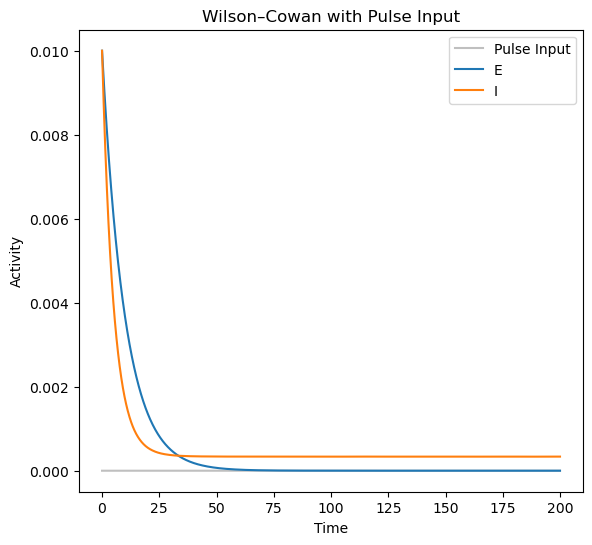

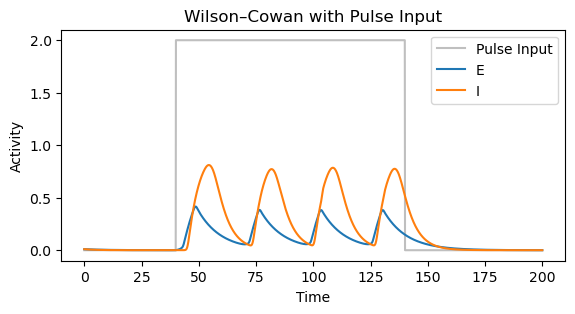

<Figure size 650x300 with 0 Axes>

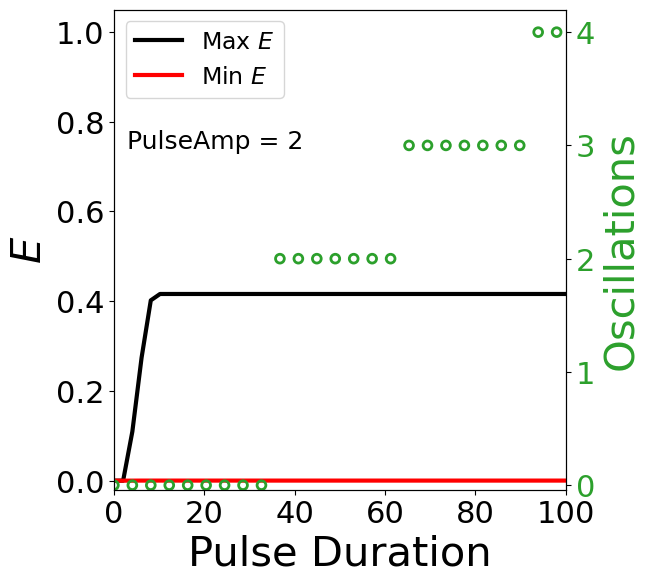

In [3]:
## bifurcation sweep over pulse duration for a fixed pulse amplitude

def Bifrcation_Sweep_Pulse_Duration(PulseAmp):
    Duration_values = np.linspace(0, 100, 50)
    E_max = []
    E_min = []
    E_period = []
    for pulse_duration in Duration_values:
        ### solve once on dense grid
        sol = solve_ivp(
            lambda t, y: wc_with_pulse(t, y, pulse_start, pulse_duration, PulseAmp),
            (0, 200),
            [0.01, 0.01],
            t_eval=np.linspace(0, 200, 2000)
        )

        ###Show example time series for a few pulse durations
        if pulse_duration in [0, 5, 10, 20, 50, 100]:
            WC_TS_plot(sol.t, [pulse_input(ti, pulse_start, pulse_duration, PulseAmp) for ti in sol.t], sol.y) 

        ### pulse window: t in [pulse_start, pulse_start + pulse_duration]
        in_pulse = (sol.t >= pulse_start) & (sol.t <= pulse_start + pulse_duration)
        E_window = sol.y[0, in_pulse]

        ### handle zero-size window (e.g., pulse_duration = 0)
        if E_window.size == 0:
            idx0 = np.argmin(np.abs(sol.t - pulse_start))
            E0 = sol.y[0, idx0]
            E_max.append(E0)
            E_min.append(E0)
            E_period.append(0)
            continue

        E_max.append(np.max(E_window))
        E_min.append(np.min(E_window))

        ### obtain number of oscillations during pulse
        peaks, _ = find_peaks(E_window, height=0.1)
        if len(peaks) > 1:
            E_period.append(len(peaks))
        else:
            E_period.append(0)  # No oscillation or only one peak
    return Duration_values, E_max, E_min, E_period

def plot_bifurcation_pulse_duration(PulseAmp, Duration_values, E_max, E_min, E_period):
    plt.figure()
    fig_size = plt.rcParams["figure.figsize"]  
    fig_size[0] = 6.5
    fig_size[1] = 6
    plt.rcParams["figure.figsize"] = fig_size  
    fig, ax1 = plt.subplots()

    ###put a text inside ax1 for the PulseAmp
    ax1.text(
        0.03, 0.75, f"PulseAmp = {PulseAmp}",
        transform=ax1.transAxes,
        fontsize=18,
        va='top'
    )

    ax1.set_xlabel("Pulse Duration", fontsize=30)    
    ax1.set_ylabel("$E$", fontsize=30, color='k')
    ax1.plot(Duration_values, E_max, linewidth=3, label='Max $E$', color='k')
    ax1.plot(Duration_values, E_min, linewidth=3, label='Min $E$', color='red')
    ax1.tick_params(axis='y', labelcolor='k')
    ax1.set_xlim(0,100)
    ax1.set_ylim(-0.02,1.05)
    ###increase font size of x and y ticks
    plt.xticks(fontsize=22)
    plt.yticks(fontsize=22)
    ax2 = ax1.twinx()
    color = 'tab:green'
    ax2.set_ylabel('Oscillations', fontsize=30, color=color)
    ###skip even values of duration for scatter plot to avoid overcrowding
    Duration_values_skip = Duration_values[::2]
    E_period_skip = [E_period[i] for i in range(len(E_period)) if i % 2 == 0]
    ax2.scatter(Duration_values_skip, E_period_skip, s=40, marker='o', facecolors='none', linewidth=2, edgecolors=color)
    ax2.set_ylim(-0.02, 6)
    ###only major ticks for y2
    ax2.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax2.tick_params(axis='y', labelcolor=color)
    fig.tight_layout()
    ###increase font size of x and y ticks
    plt.xticks(fontsize=22)
    plt.yticks(fontsize=22)
    plt.xlim(0,100)
    plt.ylim(-0.04,4.2)
    ###join legends of both axes
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    plt.legend(handles1 + handles2, labels1 + labels2, fontsize=17, loc='upper left')
    plt.show()

PulseAmp=2
Duration_values, E_max, E_min, E_period = Bifrcation_Sweep_Pulse_Duration(PulseAmp)
plot_bifurcation_pulse_duration(PulseAmp, Duration_values, E_max, E_min, E_period)

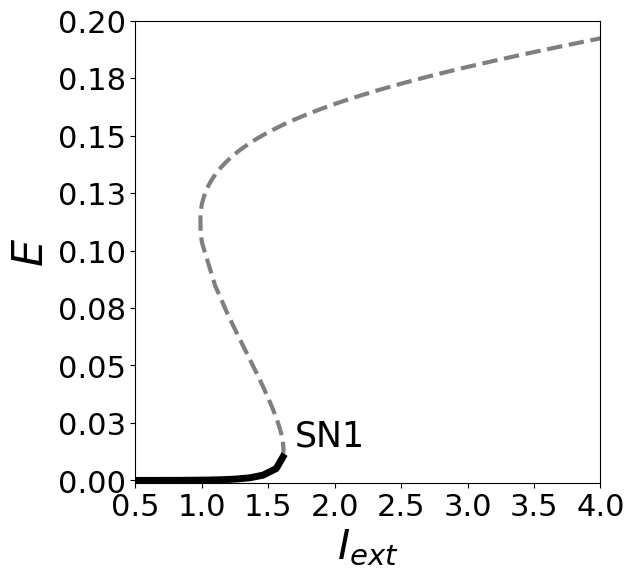

In [8]:
WCDataDirectory = "C:/Personal/work/Cell_DigitalTwin/WC_Neuron/"
SaveDir = 'C:/Personal/work/Cell_DigitalTwin/WC_Neuron/Data'

WC_Bif = np.loadtxt(os.path.join(WCDataDirectory, "WC_Bif_Clean.dat")).T

WC_Bif.shape

fig_size = plt.rcParams["figure.figsize"]  
fig_size[0] = 6
fig_size[1] = 6
plt.rcParams["figure.figsize"] = fig_size  

a=15; b=30

plt.plot(WC_Bif[0, :a], WC_Bif[1, :a], 'k', linewidth=5)
plt.plot(WC_Bif[0, a-1:], WC_Bif[1, a-1:], 'k', linewidth=3, ls='--', alpha=0.5)
# plt.plot(WC_Bif[0, b:], WC_Bif[1, b:], 'k', linewidth=5)

plt.text(1.7, 0.015, 'SN1', fontsize=25)

plt.xlabel('$I_{ext}$', fontsize=30)
plt.ylabel('$E$', fontsize=31)

plt.xlim(0.5,4)
plt.ylim(-0.001,0.2)

###round y axis to 2 decimal places
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

plt.xticks(fontsize=22)
plt.yticks(fontsize=22)

# plt.savefig('Fig_Res1.3.0.svg', bbox_inches='tight')

plt.show()

# 2. Generate Train and test Data

In [5]:
def two_pulse_input(t, start1, start2, duration, amp):
    """return amplitude while t is within [start, start+duration]"""
    return amp if (start1 < t < start1 + duration) or (start2 < t < start2 + duration) else 0.0

def wc_with_2pulse(t, y, start1, start2, duration, amp):
    return wilson_cowan(t, y, two_pulse_input(t, start1, start2, duration, amp))

def WC_Solve_2pulses(T_max, step, pulse_start1, pulse_start2, pulse_duration, pulse_amp, Plot=False):
    Pts = int(np.floor(T_max/step))

    t_span = (0.0, T_max)
    t_eval = np.linspace(*t_span, Pts)
    # integrate, passing the pulse parameters via a lambda
    sol = solve_ivp(lambda t, y: wc_with_2pulse(t, y,
                                            pulse_start1,
                                            pulse_start2,
                                            pulse_duration,
                                            pulse_amp),
                    t_span, y0, t_eval=t_eval)

    # generate pulse input series for plotting
    pulse_input_series = np.array([two_pulse_input(ti,
                                            pulse_start1,
                                            pulse_start2,
                                            pulse_duration,
                                            pulse_amp)
                                for ti in t_eval])
    time = np.array(sol.t)
    Input = np.array(pulse_input_series)
    Sol = np.array([sol.y[0], sol.y[1]])

    if Plot == True:
        WC_TS_plot(time, Input, Sol)
    return time, Input, Sol

def generate_WC_Data(PulseAmps, pulse_start1, pulse_start2, pulse_duration):
    Inputs = []
    Sols = []
    for i in range(len(PulseAmps)):
        print(f"Simulating for PulseAmp = {PulseAmps[i]}...")
        time, Input, Sol = WC_Solve_2pulses(T_max, step, pulse_start1[i], pulse_start2[i], pulse_duration, PulseAmps[i], Plot=True)
        Inputs.append(Input[::10])
        Sols.append(Sol[:,::10])

    return np.array(Inputs), np.array(Sols)

In [6]:
###three pulses
def three_pulse_input(t, start1, start2, start3, duration, amp):
    """return amplitude while t is within [start, start+duration]"""
    return amp if (start1 < t < start1 + duration) or (start2 < t < start2 + duration) or (start3 < t < start3 + duration) else 0.0

def wc_with_3pulse(t, y, start1, start2, start3, duration, amp):
    return wilson_cowan(t, y, three_pulse_input(t, start1, start2, start3, duration, amp))

def WC_Solve_3pulses(T_max, step, pulse_start1, pulse_start2, pulse_start3, pulse_duration, pulse_amp, Plot=False):
    Pts = int(np.floor(T_max/step))

    t_span = (0.0, T_max)
    t_eval = np.linspace(*t_span, Pts)
    # integrate, passing the pulse parameters via a lambda
    sol = solve_ivp(lambda t, y: wc_with_3pulse(t, y,
                                            pulse_start1,
                                            pulse_start2,
                                            pulse_start3,
                                            pulse_duration,
                                            pulse_amp),
                    t_span, y0, t_eval=t_eval)

    # generate pulse input series for plotting
    pulse_input_series = np.array([three_pulse_input(ti,
                                            pulse_start1,
                                            pulse_start2,
                                            pulse_start3,
                                            pulse_duration,
                                            pulse_amp)
                                for ti in t_eval])
    time = np.array(sol.t)
    Input = np.array(pulse_input_series)
    Sol = np.array([sol.y[0], sol.y[1]])

    if Plot == True:
        WC_TS_plot(time, Input, Sol)
    return time, Input, Sol

def generate_WC_Data_3pulses(PulseAmps, pulse_start1, pulse_start2, pulse_start3, pulse_duration):
    Inputs = []
    Sols = []
    for i in range(len(PulseAmps)):
        print(f"Simulating for PulseAmp = {PulseAmps[i]}...")
        time, Input, Sol = WC_Solve_3pulses(T_max, step, pulse_start1[i], pulse_start2[i], pulse_start3[i], pulse_duration, PulseAmps[i], Plot=True)
        Inputs.append(Input[::10])
        Sols.append(Sol[:,::10])

    return np.array(Inputs), np.array(Sols)

Simulating for PulseAmp = 3.1...


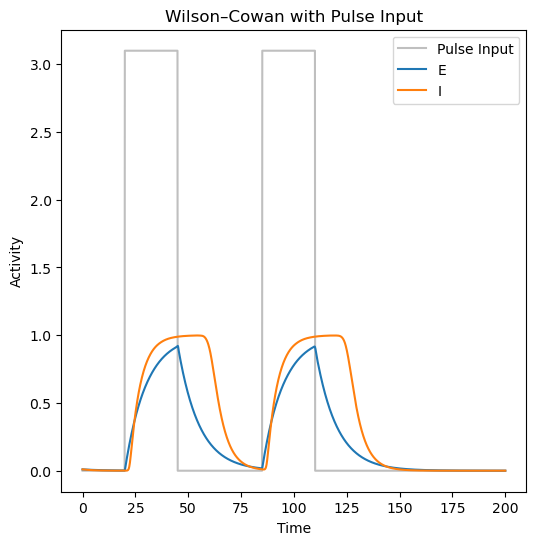

Simulating for PulseAmp = 2.25...


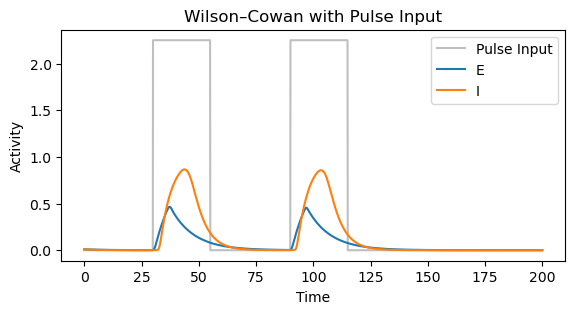

Simulating for PulseAmp = 3.2...


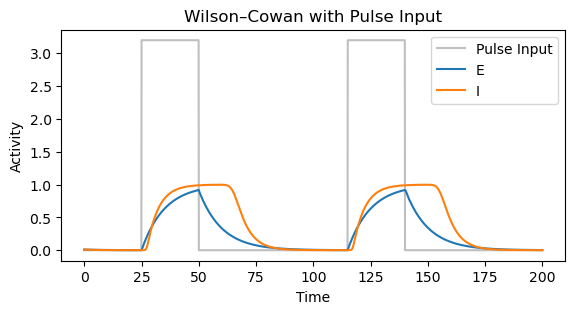

Simulating for PulseAmp = 2.4...


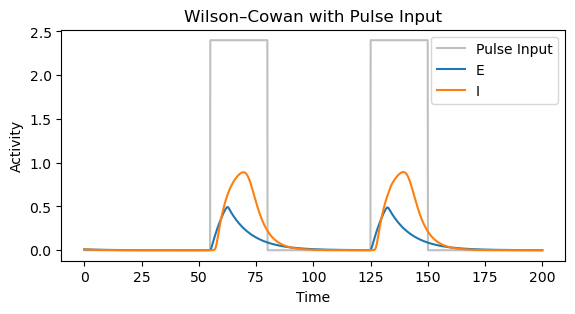

Simulating for PulseAmp = 3.3...


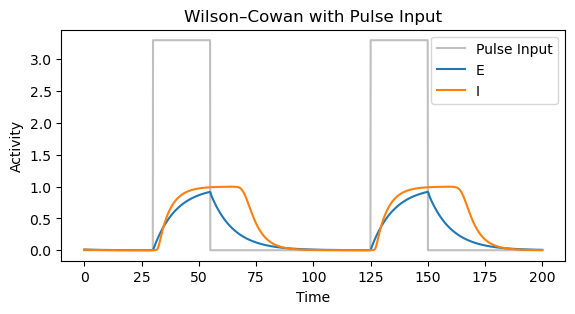

Simulating for PulseAmp = 2.1...


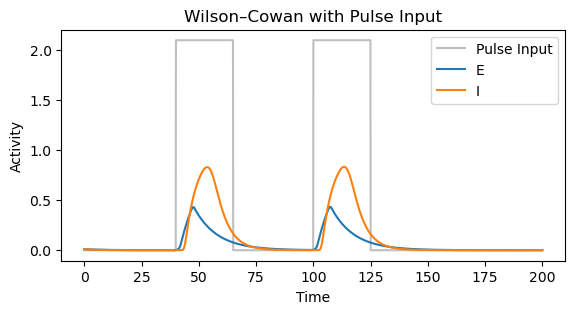

Inputs shape: (6, 200)
Sols shape: (6, 2, 200)
Simulating for PulseAmp = 2.35...


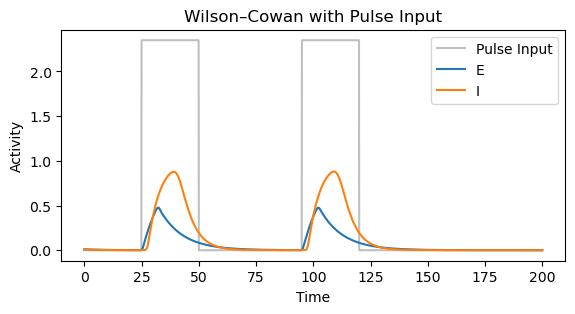

Simulating for PulseAmp = 3.15...


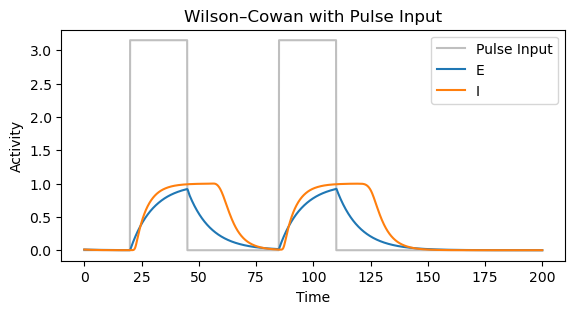

Simulating for PulseAmp = 3.25...


C:\Users\manis\AppData\Local\Temp\ipykernel_29400\2061159686.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-a * (x - theta)))


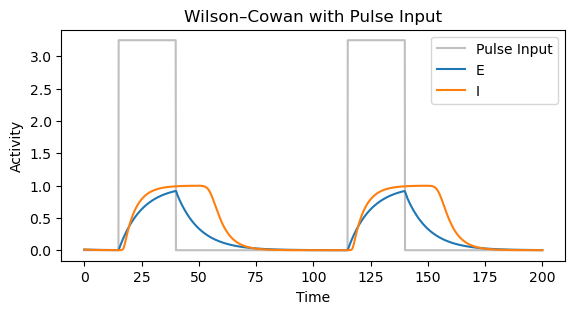

Simulating for PulseAmp = 2.15...


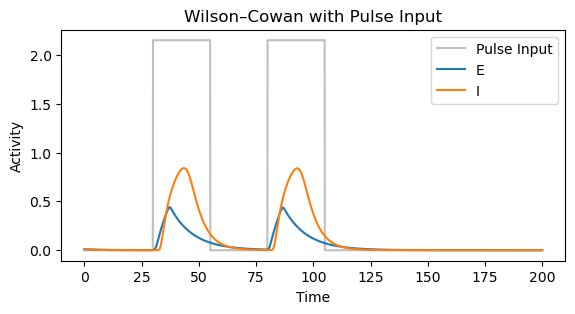

Simulating for PulseAmp = 3.15...


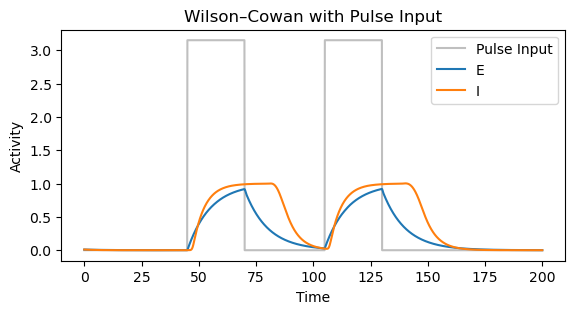

Simulating for PulseAmp = 2.3...


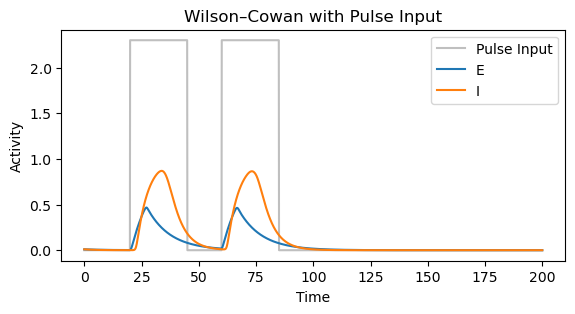

Test Inputs shape: (6, 200)
Test Sols shape: (6, 2, 200)
Simulating for PulseAmp = 2.2...


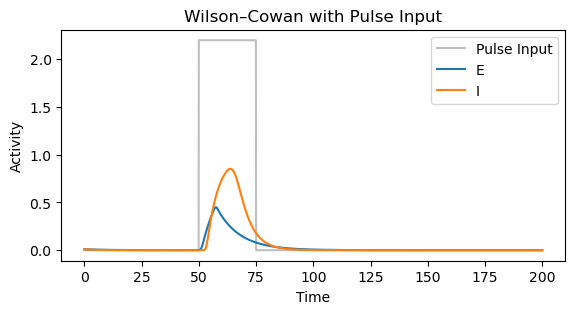

Simulating for PulseAmp = 2.35...


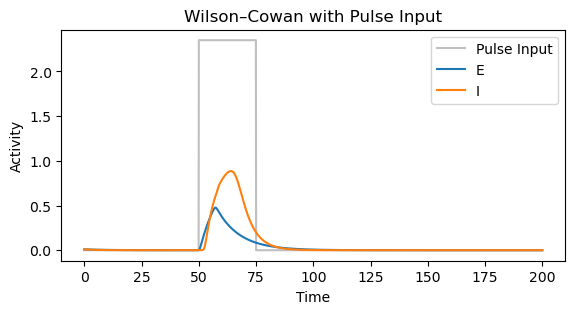

Simulating for PulseAmp = 2.45...


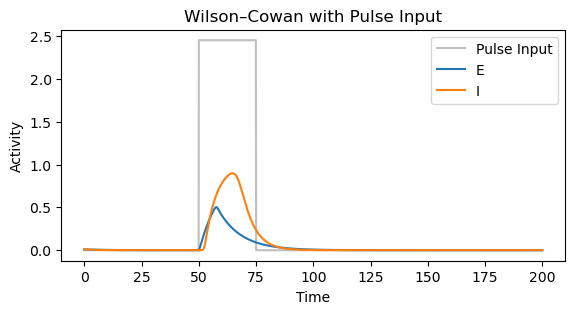

Simulating for PulseAmp = 3.15...


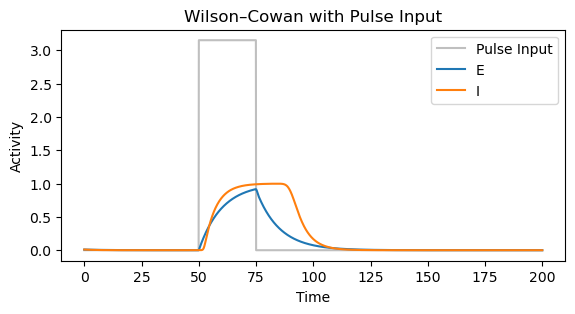

Simulating for PulseAmp = 3.25...


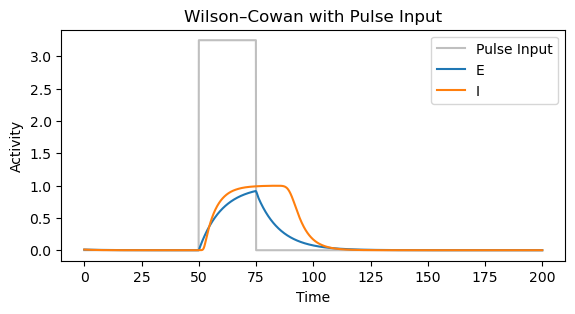

Simulating for PulseAmp = 3.32...


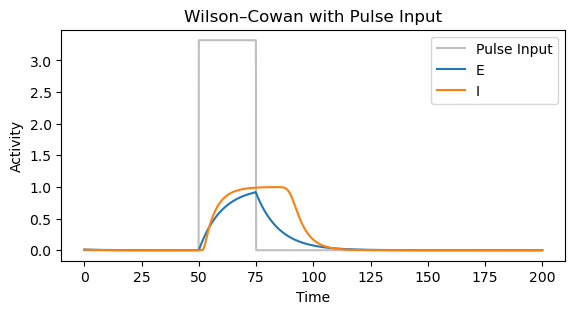

Predict Inputs shape: (6, 200)
Predict Sols shape: (6, 2, 200)
Simulating for PulseAmp = 2.2...


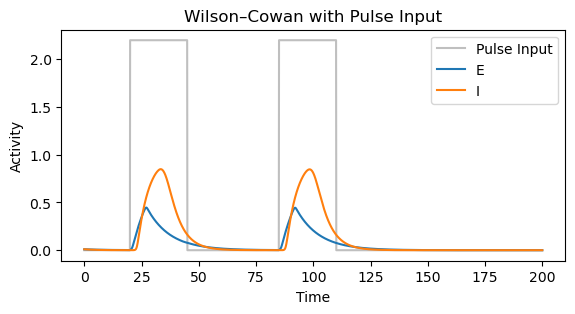

Simulating for PulseAmp = 2.35...


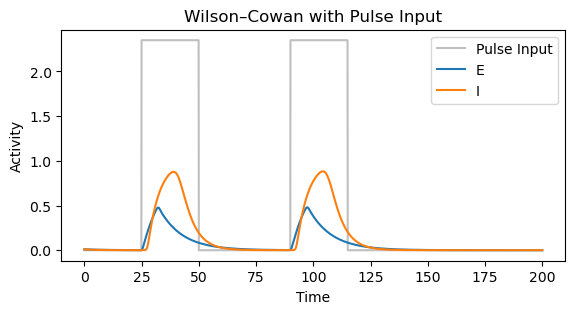

Simulating for PulseAmp = 2.45...


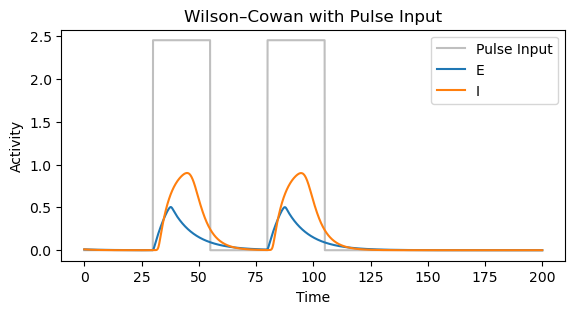

Simulating for PulseAmp = 3.15...


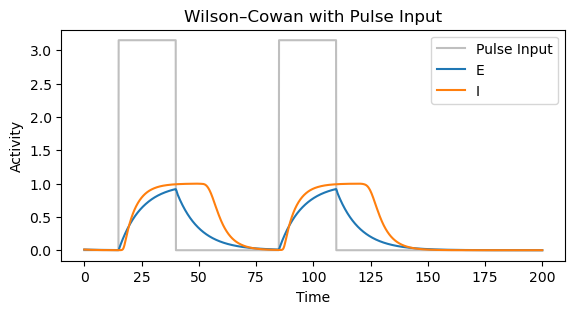

Simulating for PulseAmp = 3.25...


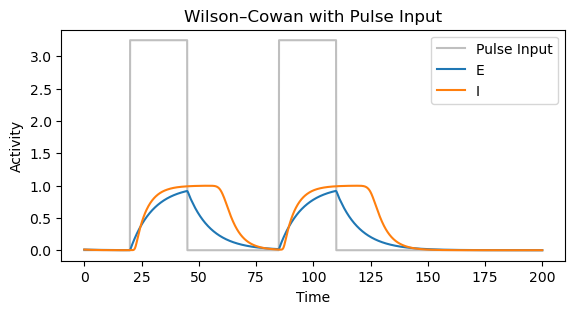

Simulating for PulseAmp = 3.32...


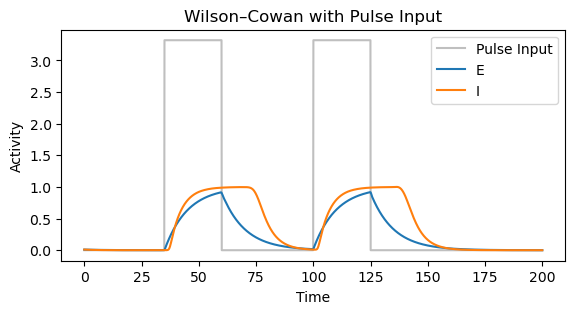

Predict Inputs shape (2 pulses): (6, 200)
Predict Sols shape (2 pulses): (6, 2, 200)
Simulating for PulseAmp = 2.2...


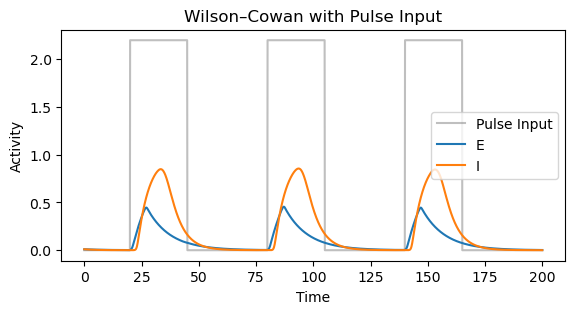

Simulating for PulseAmp = 2.35...


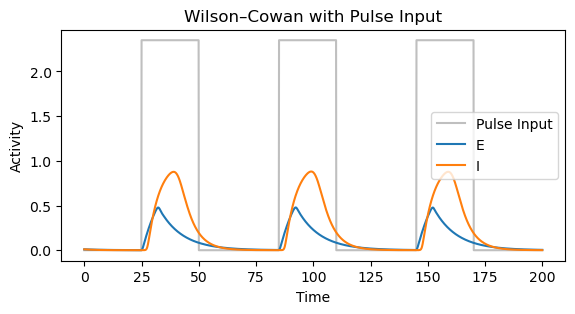

Simulating for PulseAmp = 2.45...


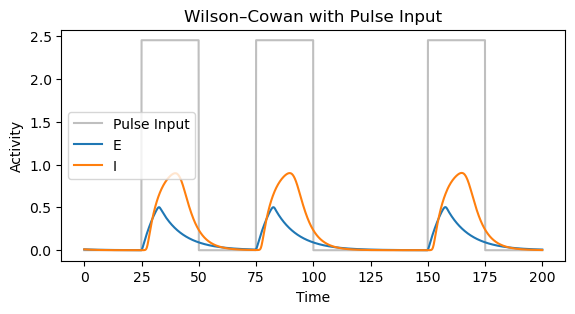

Simulating for PulseAmp = 3.15...


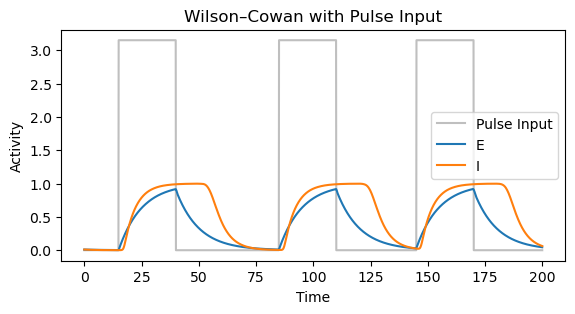

Simulating for PulseAmp = 3.25...


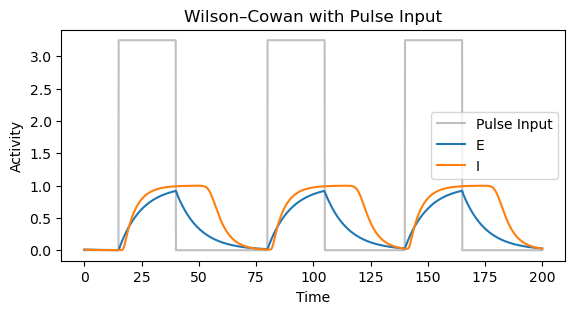

Simulating for PulseAmp = 3.32...


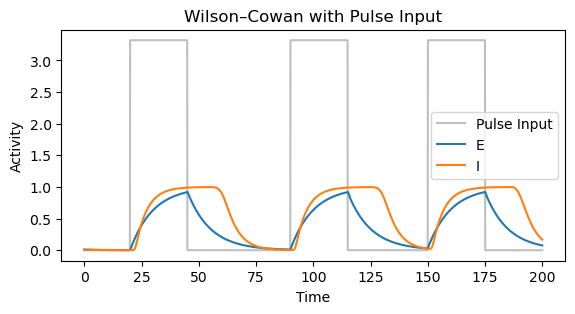

Predict Inputs shape (3 pulses): (6, 200)
Predict Sols shape (3 pulses): (6, 2, 200)
Final Predict Inputs shape: (18, 200)
Final Predict Sols shape: (18, 2, 200)


In [9]:
### Generate Trainning data for fixed pulse duration and varying pulse amplitude

Train_PulseAmps = np.array([3.1, 2.25, 3.2, 2.4, 3.3, 2.1])  #[1.75, 1.85, 2.0, 2.25, 2.5, 3.0, 3.2, 3.3])
Test_PulseAmps = np.array([2.35, 3.15, 3.25, 2.15, 3.15, 2.3])   #[1.8, 1.95, 2.05, 2.35, 2.4, 2.75, 3.1, 3.25]) 

##using 2 pulses
pulse_start_train1 = [20, 30, 25, 55, 30, 40]##40.0
pulse_start_train2 = [85, 90, 115, 125, 125, 100]##40.0

pulse_start_test1 = [25, 20, 15, 30, 45, 20]
pulse_start_test2 = [95, 85, 115, 80, 105, 60]

pulse_duration = 25.0 #Good Thanh = 25 #oscillatory = 60.0
Train_Inputs, Train_Sols = generate_WC_Data(Train_PulseAmps, pulse_start_train1, pulse_start_train2, pulse_duration)
print("Inputs shape:", Train_Inputs.shape)  # Should be (6, 1000)
print("Sols shape:", Train_Sols.shape)      # Should be (6, 2, 1000)

Test_Inputs, Test_Sols = generate_WC_Data(Test_PulseAmps, pulse_start_test1, pulse_start_test2, pulse_duration)
print("Test Inputs shape:", Test_Inputs.shape)  # Should be (6, 1000)
print("Test Sols shape:", Test_Sols.shape)      # Should be (6, 2, 1000)



####Prediction data 1 pulse
Predict_1_PulseAmps = np.array([2.2, 2.35, 2.45, 3.15, 3.25, 3.32])
pulse_start_predict1 = [50, 50, 50, 50, 50, 50]
pulse_start_predict2 = [50, 50, 50, 50, 50, 50]
Predict_Inputs, Predict_Sols = generate_WC_Data(Predict_1_PulseAmps, pulse_start_predict1, pulse_start_predict2, pulse_duration)
print("Predict Inputs shape:", Predict_Inputs.shape)  # Should be (6, 1000)
print("Predict Sols shape:", Predict_Sols.shape)      # Should be (6, 2, 1000)
#### Prediction data 2 pulses
Predict_2_PulseAmps = np.array([2.2, 2.35, 2.45, 3.15, 3.25, 3.32])
pulse_start_predict1_2pulses = [20, 25, 30, 15, 20, 35]
pulse_start_predict2_2pulses = [85, 90, 80, 85, 85, 100]

Predict_Inputs_2pulses, Predict_Sols_2pulses = generate_WC_Data(Predict_2_PulseAmps, pulse_start_predict1_2pulses, pulse_start_predict2_2pulses, pulse_duration)
print("Predict Inputs shape (2 pulses):", Predict_Inputs_2pulses.shape)  # Should be (6, 1000)
print("Predict Sols shape (2 pulses):", Predict_Sols_2pulses.shape)      # Should be (6, 2, 1000)

#### Prediction data 3 pulses
Predict_3_PulseAmps = np.array([2.2, 2.35, 2.45, 3.15, 3.25, 3.32])
pulse_start_predict1_3pulses = [20, 25, 25, 15, 15, 20]
pulse_start_predict2_3pulses = [80, 85, 75, 85, 80, 90]
pulse_start_predict3_3pulses = [140, 145, 150, 145, 140, 150]

Predict_Inputs_3pulses, Predict_Sols_3pulses = generate_WC_Data_3pulses(Predict_3_PulseAmps, pulse_start_predict1_3pulses, pulse_start_predict2_3pulses, pulse_start_predict3_3pulses, pulse_duration)
print("Predict Inputs shape (3 pulses):", Predict_Inputs_3pulses.shape)  # Should be (6, 1000)
print("Predict Sols shape (3 pulses):", Predict_Sols_3pulses.shape)      # Should be (6, 2, 1000)

###join the 1, 2, and 3 pulse prediction data together
Predict_Inputs = np.concatenate((Predict_Inputs, Predict_Inputs_2pulses, Predict_Inputs_3pulses), axis=0)
Predict_Sols = np.concatenate((Predict_Sols, Predict_Sols_2pulses, Predict_Sols_3pulses), axis=0)
print("Final Predict Inputs shape:", Predict_Inputs.shape)  # Should be (18, 1000)
print("Final Predict Sols shape:", Predict_Sols.shape)      # Should be (18, 2, 1000)

# ##save the generated dataSols)
np.save(os.path.join(SaveDir, "WC_Train_Inputs.npy"), Train_Inputs)
np.save(os.path.join(SaveDir, "WC_Train_Sols.npy"), Train_Sols)
np.save(os.path.join(SaveDir, "WC_Test_Inputs.npy"), Test_Inputs)
np.save(os.path.join(SaveDir, "WC_Test_Sols.npy"), Test_Sols)
np.save(os.path.join(SaveDir, "WC_Predict_Inputs.npy"), Predict_Inputs)
np.save(os.path.join(SaveDir, "WC_Predict_Sols.npy"), Predict_Sols)